In [ ]:
import tensorflow as tf    # I use TensorFlow to train an image classification model that detects crop diseases from leaf images.

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt # used for data visualisation

In [ ]:
import os # used for access and manage the dataset

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset downloaded at:", dataset_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded at: /kaggle/input/plantvillage-dataset


In [ ]:
os.listdir(dataset_path) # check folder structure

['plantvillage dataset']

In [ ]:
main_folder = os.path.join(dataset_path, "plantvillage dataset")
                               #to create the correct path to the main dataset folder
os.listdir(main_folder)

['segmented', 'grayscale', 'color']

In [ ]:
data_dir = os.path.join(main_folder, "color")
                        #to create the path of the color image
os.listdir(data_dir)

['Tomato___Late_blight',
 'Tomato___healthy',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Potato___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Tomato___Early_blight',
 'Tomato___Septoria_leaf_spot',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Strawberry___Leaf_scorch',
 'Peach___healthy',
 'Apple___Apple_scab',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Bacterial_spot',
 'Apple___Black_rot',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Peach___Bacterial_spot',
 'Apple___Cedar_apple_rust',
 'Tomato___Target_Spot',
 'Pepper,_bell___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Potato___Late_blight',
 'Tomato___Tomato_mosaic_virus',
 'Strawberry___healthy',
 'Apple___healthy',
 'Grape___Black_rot',
 'Potato___Early_blight',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Common_rust_',
 'Grape___Esca_(Black_Measles)',
 'Raspberry___healthy'

In [ ]:
class_names = os.listdir(data_dir)   # checking the number of classes to determine the output size of the model.

print("Total Classes:", len(class_names))
print("First 5 Classes:", class_names[:5])

Total Classes: 38
First 5 Classes: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [ ]:
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_count = len(os.listdir(class_path))
## Checking the number of images in each class to understand the dataset distribution
    print(class_name, ":", image_count)

Tomato___Late_blight : 1909
Tomato___healthy : 1591
Grape___healthy : 423
Orange___Haunglongbing_(Citrus_greening) : 5507
Soybean___healthy : 5090
Squash___Powdery_mildew : 1835
Potato___healthy : 152
Corn_(maize)___Northern_Leaf_Blight : 985
Tomato___Early_blight : 1000
Tomato___Septoria_leaf_spot : 1771
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513
Strawberry___Leaf_scorch : 1109
Peach___healthy : 360
Apple___Apple_scab : 630
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 5357
Tomato___Bacterial_spot : 2127
Apple___Black_rot : 621
Blueberry___healthy : 1502
Cherry_(including_sour)___Powdery_mildew : 1052
Peach___Bacterial_spot : 2297
Apple___Cedar_apple_rust : 275
Tomato___Target_Spot : 1404
Pepper,_bell___healthy : 1478
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1076
Potato___Late_blight : 1000
Tomato___Tomato_mosaic_virus : 373
Strawberry___healthy : 456
Apple___healthy : 1645
Grape___Black_rot : 1180
Potato___Early_blight : 1000
Cherry_(including_sour)___healthy : 854
Corn_

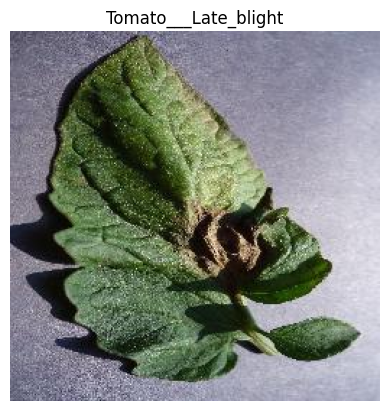

In [ ]:
sample_class = class_names[0]

sample_class_path = os.path.join(data_dir, sample_class)

sample_image_name = os.listdir(sample_class_path)[0]

sample_image_path = os.path.join(sample_class_path, sample_image_name)

img = plt.imread(sample_image_path) # Loading and displaying a sample image to verify the dataset

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [ ]:
print("Image Shape:", img.shape) #  Checking image shape, data type, and pixel value range before preprocessing
print("Image Data Type:", img.dtype)
print("Minimum Pixel Value:", img.min())
print("Maximum Pixel Value:", img.max())

Image Shape: (256, 256, 3)
Image Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # Loading 80% of the images as the training dataset
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [ ]:
# Loading the remaining 20% images as the validation dataset
# Validation data is used to check model performance on images not used for training

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    data_dir,                  # Path containing all 38 class folders

    validation_split=0.2,      # Same 20% validation split used while creating training dataset

    subset="validation",       # Load only the validation portion (20% of total images)

    seed=123,                  # Same seed ensures correct and consistent train-validation split

    image_size=(224, 224),     # Resize validation images to the same size as training images

    batch_size=32              # Load 32 validation images at a time
)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
# ==========================================================
# FIX: Save the class names in the EXACT order Keras assigned
# ==========================================================
# image_dataset_from_directory() assigns label indices based on the
# ALPHABETICALLY SORTED folder names, NOT the order os.listdir() returned
# back in Cell 8. train_dataset.class_names gives us the true, guaranteed
# mapping between output neuron index and disease name.

class_names = train_dataset.class_names

print("Total Classes (from train_dataset):", len(class_names))
print(class_names)

import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

print("\nSaved class_names.json - this MUST be shipped alongside the .keras model file.")


In [ ]:
# Taking one batch from the training dataset to check
# the shape of images and labels before giving them to the model

for images, labels in train_dataset.take(1):

    print("Images Batch Shape:", images.shape)
    print("Labels Batch Shape:", labels.shape)

Images Batch Shape: (32, 224, 224, 3)
Labels Batch Shape: (32,)


In [ ]:
# Creating a normalization layer to convert pixel values
# from 0-255 range into 0-1 range

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
# Creating data augmentation layers
# These layers create random variations of training images
# to help the model generalize better to new leaf images

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),  # Randomly flips some images horizontally

    tf.keras.layers.RandomRotation(0.1),       # Randomly rotates images slightly

    tf.keras.layers.RandomZoom(0.1)            # Randomly zooms images slightly
])

In [ ]:
# Creating the CNN model step by step

model = tf.keras.Sequential([

    # Input image size: 224x224 pixels with 3 RGB channels
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Creates random variations of images during training
    data_augmentation,

    # Converts pixel values from 0-255 to 0-1
    normalization_layer,

    # First convolution layer learns basic features
    # such as edges, spots, and simple textures
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Reduces the feature map size
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution layer learns more complex features
    # from the features detected by the first layer
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Again reduces the feature map size
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
])

In [ ]:
# Third Convolution Layer
model.add(
    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu"
    )
)

# Third Max Pooling Layer
model.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
)

# Converts feature maps into a 1D feature vector
model.add(
    tf.keras.layers.GlobalAveragePooling2D()
)

# Dense layer for learning feature combinations
model.add(
    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    )
)

ValueError: Input 0 with name 'None' of layer 'conv2d_14' is incompatible with the layer: expected min_ndim=4, found ndim=2. Full shape received: (None, 128)

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    normalization_layer,

    # First Convolution Block
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convert feature maps into 1D vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense layer
    tf.keras.layers.Dense(128, activation="relu")
])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,760 (428.75 KB)

 Trainable params: 109,760 (428.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Final output layer for classifying images into 38 classes

model.add(
    tf.keras.layers.Dense(
        units=38,              # One output neuron for each class
        activation="softmax"   # Converts outputs into class probabilities
    )
)

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,662 (447.90 KB)

 Trainable params: 114,662 (447.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Configuring the model before training
# Defines how the model will learn, calculate errors,
# and measure its performance

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
# Stop training when validation loss stops improving
# This helps prevent unnecessary training and overfitting

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",          # Monitor validation loss
    patience=3,                  # Wait for 3 epochs before stopping
    restore_best_weights=True    # Restore the model weights from the best epoch
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 145s 102ms/step - accuracy: 0.4195 - loss: 2.0474 - val_accuracy: 0.6079 - val_loss: 1.2890
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.6710 - loss: 1.0756 - val_accuracy: 0.6711 - val_loss: 1.0585
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.7688 - loss: 0.7433 - val_accuracy: 0.7714 - val_loss: 0.7370
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/step - accuracy: 0.8118 - loss: 0.5939 - val_accuracy: 0.8175 - val_loss: 0.5776
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.8452 - loss: 0.4875 - val_accuracy: 0.8505 - val_loss: 0.4802


In [ ]:
import tensorflow as tf
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

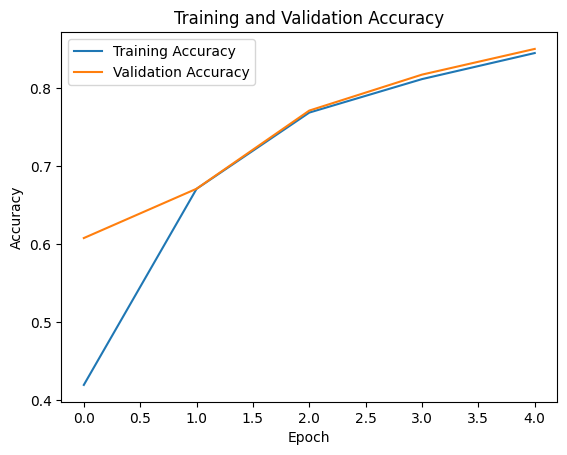

In [ ]:
# Plotting training and validation accuracy
# to visualize how model performance changed during training

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

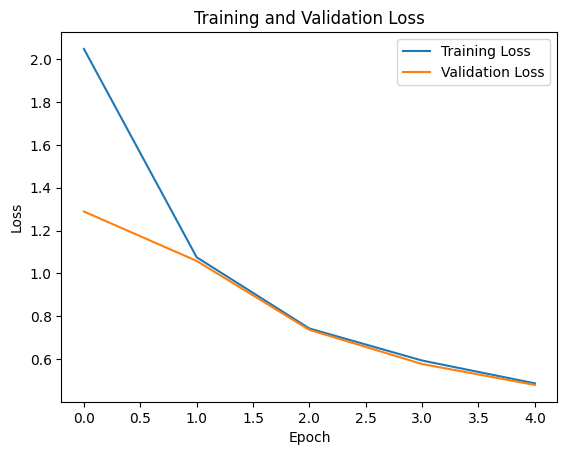

In [ ]:
# Plotting training and validation loss
# to check how the model's prediction error changed during training

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
# Evaluating the trained model on the validation dataset
# to measure its final loss and accuracy on unseen images

validation_loss, validation_accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.8505 - loss: 0.4802
Validation Loss: 0.4801504611968994
Validation Accuracy: 0.8504741787910461


In [ ]:
for images, labels in validation_dataset.take(1):
    test_image = images[0]
    true_label = labels[0]
    break

In [ ]:
# Adding a batch dimension because the model expects multiple images as input
input_image = tf.expand_dims(test_image, axis=0)

# Predicting probabilities for all 38 classes
predictions = model.predict(input_image)

# Finding the class index with the highest probability
predicted_index = np.argmax(predictions[0])

# Getting the predicted class name
predicted_class = class_names[predicted_index]

# Getting the actual class name
actual_class = class_names[int(true_label.numpy())]

# Getting confidence of the predicted class
confidence = np.max(predictions[0]) * 100

print("Actual Class:", actual_class)
print("Predicted Class:", predicted_class)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Actual Class: Potato___Late_blight
Predicted Class: Potato___Late_blight
Confidence: 57.62998 %


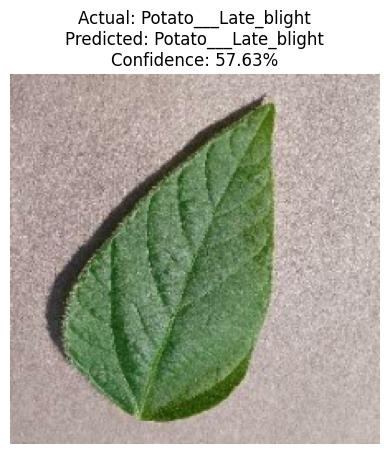

In [ ]:
# Displaying the tested leaf image with actual and predicted class names

plt.imshow(test_image.numpy().astype("uint8"))

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
# Saving the complete trained model
# This file will later be loaded in the FastAPI backend for predictions

model.save("crop_disease_model.keras")

In [ ]:
from google.colab import files

files.download("crop_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download the class names file too - it MUST travel with the model.
# The FastAPI backend loads this instead of a hardcoded list, so the
# index -> disease name mapping can never drift out of sync again.
files.download("class_names.json")
